In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DB_PATH = Path("..") / "data" / "olist.db"
conn = sqlite3.connect(DB_PATH)



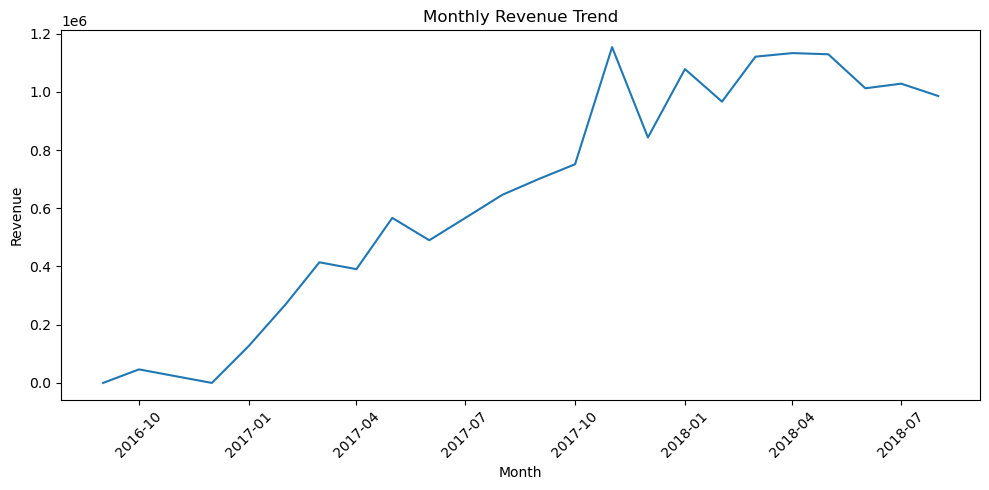

In [2]:
query = """
SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) AS order_month,
    SUM(oi.price + oi.freight_value) AS revenue
FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY order_month
ORDER BY order_month;
"""

revenue = pd.read_sql(query, conn)
revenue["order_month"] = pd.to_datetime(revenue["order_month"])

plt.figure(figsize=(10,5))
plt.plot(revenue["order_month"], revenue["revenue"])
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

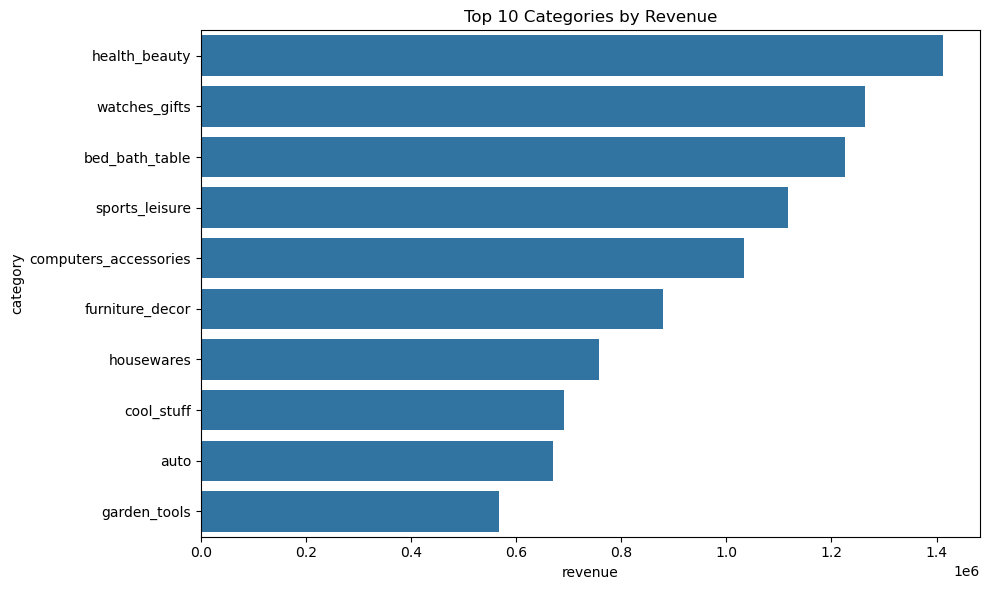

In [3]:
query = """
SELECT
    COALESCE(t.product_category_name_english, p.product_category_name) AS category,
    SUM(oi.price + oi.freight_value) AS revenue
FROM order_items oi
JOIN orders o ON oi.order_id = o.order_id
JOIN products p ON oi.product_id = p.product_id
LEFT JOIN category_translation t
ON p.product_category_name = t.product_category_name
WHERE o.order_status = 'delivered'
GROUP BY category
ORDER BY revenue DESC
LIMIT 10;
"""

cat = pd.read_sql(query, conn)

plt.figure(figsize=(10,6))
sns.barplot(data=cat, x="revenue", y="category")
plt.title("Top 10 Categories by Revenue")
plt.tight_layout()
plt.show()

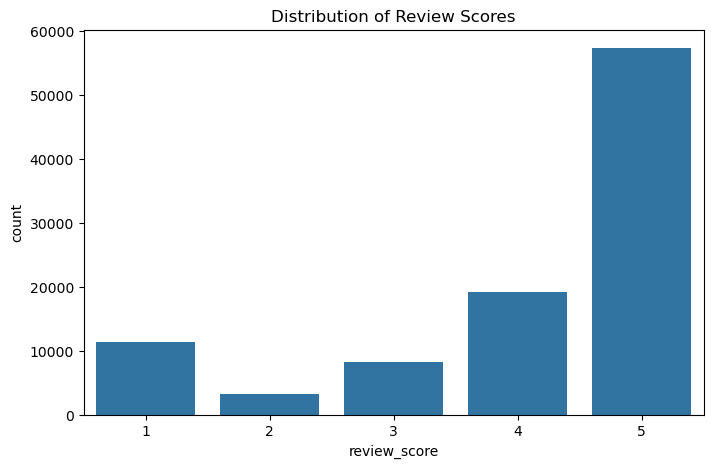

In [4]:
query = """
SELECT review_score
FROM reviews;
"""

reviews = pd.read_sql(query, conn)

plt.figure(figsize=(8,5))
sns.countplot(data=reviews, x="review_score")
plt.title("Distribution of Review Scores")
plt.show()